# TSST - Práctica 7: Predicción con redes LSTM

**Alicia Lozano Díez**

## Objetivo

El objetivo de esta práctica es proporcionar una introducción al uso de redes neuronales recurrentes (RNN) y en particular, a las Long Short-Term Memory (LSTM) para el procesamiento de series temporales y su uso en predicción. Para ello, se dividirá en dos partes basadas en dos ejemplos de datos: predicción del número de pasajeros en una aerolínea, y el problema de detección de actividad de voz (Voice Activity Detection, VAD). Esta última incluirá además una introducción al procesamiento de señales de voz.

### Materiales

- Guión (.ipynb) de la práctica - Moodle
- Ejemplos de datos y etiquetas - Moodle
- Listas de entrenamiento y validación VAD - Moodle
- Scripts de descarga de datos - Moodle
- Datos y etiquetas de entrenamiento VAD * - One Drive (https://dauam-my.sharepoint.com/:u:/g/personal/alicia_lozano_uam_es/EeHT_NXP56FLkKffjyOhfa8BqAy3EmIrMkBZ0wnyDAti1g?download=1)
- Datos y etiquetas de validación VAD * - One Drive (https://dauam-my.sharepoint.com/:u:/g/personal/alicia_lozano_uam_es/ESc5XzkpZ3ZBnGFQ6HWdn_UB38NHMOLTLtTcEE_b81Cylw?download=1)


**CUIDADO: Los datos proporcionados son de uso exclusivo para esta práctica. No tiene permiso para copiar, distribuir o utilizar el corpus para ningún otro propósito.**


# Parte 1: Predicción mediante LSTM del número de pasajeros de una aerolínea



## 1.1. Carga y visualización de los datos

Igual que hicimos en la práctica 5, vamos a descargar el fichero con los datos de la base de datos *AirPassengers.csv* de Moodle, que contiene los datos del número de pasajeros de una aerolínea para un período de tiempo.

A continuación, los cargamos en Google Colab y los visualizamos para comprobar que es el resultado esperado:

Text(0.5, 1.0, 'Serie temporal: Air Passengers')

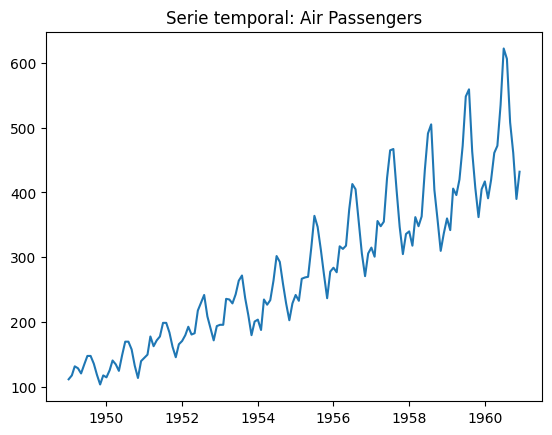

In [1]:
# Carga y visualizacion de los datos
from pandas import read_csv

data = read_csv('AirPassengers.csv', header=0, parse_dates=[0], index_col=0,
                date_format='%Y-%m')

from matplotlib import pyplot as plt
plt.plot(data)
plt.title('Serie temporal: Air Passengers')

## 1.2. Normalización o escalado

Las redes neuronales en general encuentran más dificultades para tratar con datos cuyos valores no tienen algún tipo de normalización.

Por ello, vamos a aplicar un escalado de los datos a valores entre 0 y 1 de la siguiente manera:

Text(0.5, 1.0, 'Serie temporal: Air Passengers (normalizada)')

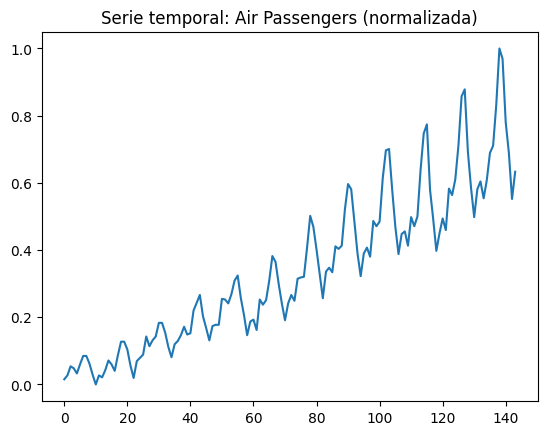

In [2]:
# 2. Normalización de los datos
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
data_norm = scaler.fit_transform(data)

plt.plot(data_norm)
plt.title('Serie temporal: Air Passengers (normalizada)')

## 1.3. Preparación de los datos y definición del modelo LSTM

Para el uso de modelos LSTM, vamos a utilizar la librería Pytorch (https://pytorch.org/docs/stable/index.html).

En particular, vamos a definir un modelo con un número de capas LSTM dadas, y una capa de salida _fully connected_:

In [3]:
# 4. Definición del modelo LSTM
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)  # Salida de la última capa LSTM
        hn = hn[-1]  # Seleccionamos el último estado oculto
        return self.fc(hn)

# Parámetros del modelo
input_size = 1
hidden_size = 20
num_layers = 2
output_size = 1

model = LSTMModel(input_size, hidden_size, num_layers, output_size)


Como se observa, los parámetros utilizados serían los siguientes:

* Tamaño de la entrada a la capa LSTM: input_size
* Unidades (celdas) de la capa LSTM: hidden_size
* Unidades de salida: output_size (capa lineal)

Además, la red LSTM espera un tensor de entrada con el tamaño del batch, la longitud de la secuencia así como la dimensionalidad del espacio de características.

La función forward permite obtener la predicción de la salida para un dato (o batch) de entrada (realiza el paso forward del modelo).

**PREGUNTA 1: Revise la documentación de _torch.nn.LSTM_ y preste atención a los argumentos batch_first, bidirectional y dropout. ¿Para qué sirven dichos argumentos? ¿Cuál es por tanto la dimensionalidad del tensor de entrada esperado en el modelo anterior?**

- **Batch_first**:Si es `True` los tensores de entrada y salida son proporcionados
- **Bidirectional**: Si es `True` se convierte en una LSTM bidireccional.
- **Dropout**: Si no es cero se introduce un Dropout layer en cada capa del LSTM excepto en la última que su probabilidad es `dropout` DEfault=0{}
  
La dimensionalidad es: $D_{input} = 1, D_{output}=1$

Para preparar las secuencias para la red LSTM a partir de los datos, utilizamos el siguiente código, que además divide la serie temporal (nuestros datos) en un 80\% para entrenamiento y un 20\% para test (o validación).

In [4]:
# 3. Preparación de los datos en secuencias para LSTM
import numpy as np
import torch

def create_sequences(data, seq_length):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length]
        sequences.append(seq)
        targets.append(label)
    return np.array(sequences), np.array(targets)

seq_length = 12  # Ventana de 12 meses
data = data_norm.squeeze(-1)
X, y = create_sequences(data, seq_length)

# División de datos en entrenamiento y prueba
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Conversión a tensores
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


**PREGUNTA 2: Compruebe que las dimensiones de los datos de entrada son las esperadas e indique qué es cada valor.**

In [5]:
print(f"X_train dimensions: {X_train.shape}")  
print(f"X_test dimensions: {X_test.shape}")


X_train dimensions: torch.Size([105, 12])
X_test dimensions: torch.Size([27, 12])


Son las esperadas ya que tenemos 105 instancias de ventanas de 12 meses, esas mismas ventanas se mantienen en test


A continuación, definimos el resto de parámetros para realizar el entrenamiento del modelo, como son el optimizador, la función de coste y los demás hiperparámetros del entrenamiento.



In [6]:
# 5. Definición del optimizador y función de pérdida
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 6. Entrenamiento del modelo
epochs = 1000
batch_size = 32

**PREGUNTA 3: ¿Qué función de coste se optimiza? ¿Por qué? ¿Qué indica el valor de _batch_size_?**

Se optimiza $MSE = \frac{1}{N}\sum_{i=1}^N(y_i - \hat{y}_i)^2$ porque es un problema de regresión y es fácil de tratar matemáticamente. 


El **`batch_size`** indica el número de muestras (secuencias de 12 meses en nuestro caso) que se procesan juntas en cada actualización de los pesos del modelo. En lugar de actualizar los pesos tras cada muestra (SGD puro) o tras recorrer todo el dataset (gradiente por lotes completo), se hace un compromiso intermedio: se calcula la pérdida sobre `batch_size` muestras, se promedia y se realiza una actualización con el gradiente resultante. Esto suaviza la estimación del gradiente respecto a SGD puro y permite paralelizar el cómputo en GPU.

Finalmente realizamos el entrenamiento del modelo durante las épocas indicadas.

In [7]:
# 6. Entrenamiento del modelo

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size].unsqueeze(-1)  # Añadimos dimensión extra
        y_batch = y_train[i:i+batch_size]

        # Forward
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


Epoch [10/1000], Loss: 0.1238
Epoch [20/1000], Loss: 0.1249
Epoch [30/1000], Loss: 0.1090
Epoch [40/1000], Loss: 0.0773
Epoch [50/1000], Loss: 0.0372
Epoch [60/1000], Loss: 0.0347
Epoch [70/1000], Loss: 0.0333
Epoch [80/1000], Loss: 0.0320
Epoch [90/1000], Loss: 0.0311
Epoch [100/1000], Loss: 0.0304
Epoch [110/1000], Loss: 0.0299
Epoch [120/1000], Loss: 0.0295
Epoch [130/1000], Loss: 0.0291
Epoch [140/1000], Loss: 0.0286
Epoch [150/1000], Loss: 0.0282
Epoch [160/1000], Loss: 0.0277
Epoch [170/1000], Loss: 0.0273
Epoch [180/1000], Loss: 0.0268
Epoch [190/1000], Loss: 0.0264
Epoch [200/1000], Loss: 0.0259
Epoch [210/1000], Loss: 0.0255
Epoch [220/1000], Loss: 0.0250
Epoch [230/1000], Loss: 0.0244
Epoch [240/1000], Loss: 0.0238
Epoch [250/1000], Loss: 0.0230
Epoch [260/1000], Loss: 0.0221
Epoch [270/1000], Loss: 0.0208
Epoch [280/1000], Loss: 0.0188
Epoch [290/1000], Loss: 0.0155
Epoch [300/1000], Loss: 0.0100
Epoch [310/1000], Loss: 0.0146
Epoch [320/1000], Loss: 0.0163
Epoch [330/1000],

**PREGUNTA 4: ¿Qué observa en la función de pérdida? ¿Tiene sentido? ¿Hacen falta más épocas?**

La pérdida disminuye de forma rápida durante las primeras épocas y luego se estabiliza en un valor pequeño, lo cual es el comportamiento esperado: el modelo está aprendiendo la estructura temporal de la serie.

Tiene sentido porque:
- La función MSE es convexa respecto a la salida y diferenciable, lo que facilita la optimización.
- La serie de pasajeros tiene un patrón estacional muy marcado de período 12 meses, y con `seq_length=12` la red ve un ciclo completo en cada secuencia de entrada.

Sobre si hacen falta más épocas: depende de si la pérdida sigue bajando de forma apreciable o ya se ha estancado. Si la curva está plana en las últimas 100–200 épocas, entrenar más solo añadiría riesgo de **sobreajuste** sin mejorar la generalización. Una buena práctica sería monitorizar también la pérdida en el conjunto de test y aplicar *early stopping* cuando ésta deje de mejorar.

## 1.4. Evaluación del modelo - Predicción de nuevos datos

Una vez entrenado el modelo, realizamos la predicción sobre el conjunto de test (20\% restante de la serie):

RMSE: 48.42


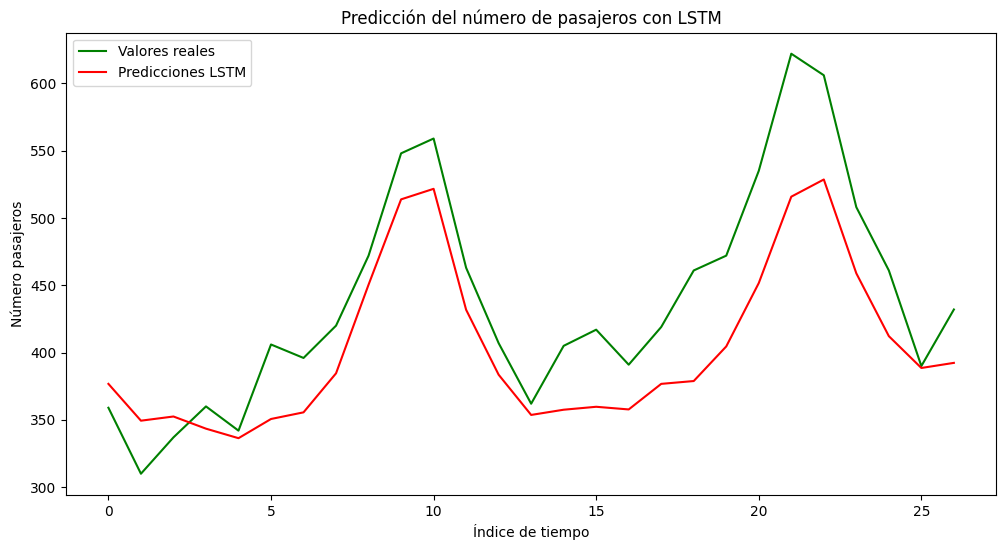

In [8]:
# 7. Predicción en el conjunto de prueba
from sklearn.metrics import mean_squared_error


model.eval()
X_test_unsqueezed = X_test.unsqueeze(-1)
predictions = model(X_test_unsqueezed).detach().numpy()

# Desescalado de las predicciones y los valores reales
y_test_descaled = scaler.inverse_transform(y_test.unsqueeze(-1).numpy())
predictions_descaled = scaler.inverse_transform(predictions)

# 8. Evaluación del modelo
mse = mean_squared_error(y_test_descaled, predictions_descaled)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# 9. Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(y_test_descaled, label='Valores reales', color='green')
plt.plot(predictions_descaled, label='Predicciones LSTM', color='red')
plt.title("Predicción del número de pasajeros con LSTM")
plt.xlabel("Índice de tiempo")
plt.ylabel("Número pasajeros")
plt.legend()
plt.show()


**PREGUNTA 5: Realice diferentes entrenamientos modificando los hiperparámetros y compare los resultados. ¿Tienen sentido?**

RMSE: 14.08


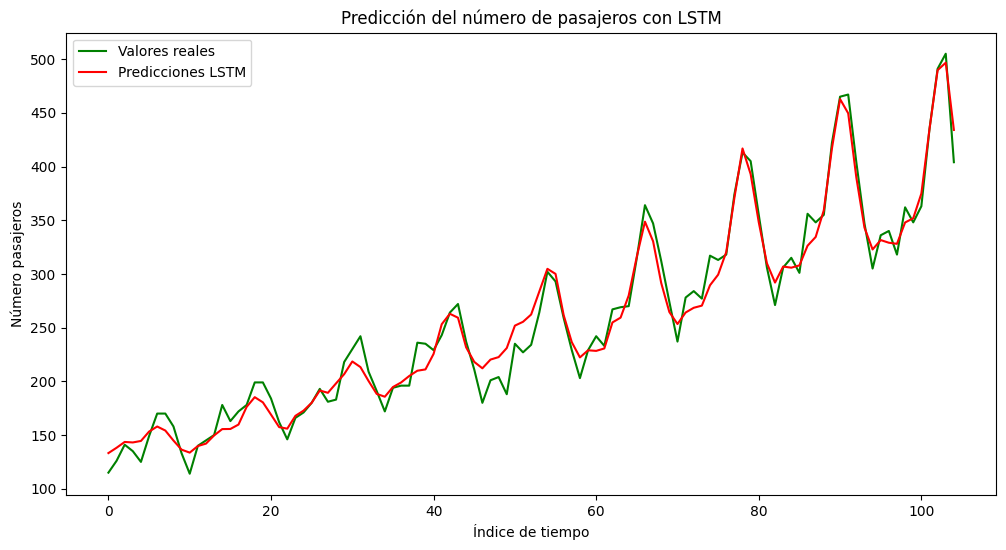

In [9]:
# 7. Predicción en el conjunto de entrenamiento ("cheating")
from sklearn.metrics import mean_squared_error


model.eval()
X_train_unsqueezed = X_train.unsqueeze(-1)
predictions = model(X_train_unsqueezed).detach().numpy()

# Desescalado de las predicciones y los valores reales
y_train_descaled = scaler.inverse_transform(y_train.unsqueeze(-1).numpy())
predictions_descaled = scaler.inverse_transform(predictions)

# 8. Evaluación del modelo
mse = mean_squared_error(y_train_descaled, predictions_descaled)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

# 9. Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(y_train_descaled, label='Valores reales', color='green')
plt.plot(predictions_descaled, label='Predicciones LSTM', color='red')
plt.title("Predicción del número de pasajeros con LSTM")
plt.xlabel("Índice de tiempo")
plt.ylabel("Número pasajeros")
plt.legend()
plt.show()

Modificando hiperparámetros se observan los siguientes efectos:

- **`hidden_size`**: aumentarlo (p.ej. de 20 a 50 o 100) da más capacidad al modelo y suele reducir el RMSE en entrenamiento, pero a partir de cierto punto el modelo memoriza ruido (sobreajuste) y el RMSE en test empeora.
- **`num_layers`**: pasar de 1 a 2 capas LSTM ayuda en problemas con dinámica compleja, pero con tan pocos datos (144 puntos) más profundidad suele perjudicar y vuelve el entrenamiento más inestable.
- **`seq_length`**: con la serie *AirPassengers* el valor natural es 12 (período estacional). Valores menores hacen que la red no vea un ciclo completo y la predicción degrada; valores mayores (24, 36) capturan tendencias a más largo plazo pero reducen el número de secuencias disponibles.
- **`lr` (learning rate)**: valores demasiado altos (0.01) producen oscilaciones; demasiado bajos (1e-5) hacen que no converja en el número de épocas dado. `1e-3` con Adam es un buen compromiso.
- **`epochs`**: más épocas reducen el error en *train* pero pueden aumentar el de *test*.

Comparando la predicción sobre *train* (celda anterior, llamada *"cheating"*) y sobre *test*, se ve claramente la diferencia entre ajuste y generalización: el RMSE en *train* es notablemente menor porque el modelo ha visto esas secuencias. Esto tiene sentido y es justamente la razón por la que se reserva un conjunto de test.

## 1.5. Aplicación a otros datos: series temporales financieras (opcional)

A continuación, podemos ampliar el trabajo elaborando un modelo basado en LSTM para los datos de series temporales financieras del S&P500 (usados en la práctica 5).

¿Hay diferencias a la hora de diseñar la red neuronal?

# Parte 2: Detección de actividad de voz (VAD)




## 2.1. Introducción al procesamiento de señales temporales de voz


### 2.1.1. Descarga de ficheros de ejemplo

Primero vamos a descargar el audio de ejemplo de Moodle (**audio_sample.wav**) y ejecutar las siguientes  líneas de código, que nos permitirán subir el archivo a Google Colab desde el disco local:

Una vez cargado el fichero de audio, podemos escucharlo de la siguiente manera:

In [10]:
import IPython

wav_file_name = "audio_sample.wav"
print(wav_file_name)
IPython.display.Audio(wav_file_name)

audio_sample.wav


### 2.1.2. Lectura y representación de audio en Python

A continuación vamos a definir ciertas funciones para poder hacer manejo de  ficheros de audio en Python.

Comenzamos definiendo una función **read_recording** que leerá un fichero de audio WAV, normalizará la amplitud y devolverá el vector de muestras _signal_ y su frecuencia de muestreo _fs_.

In [11]:
import scipy.io.wavfile

def read_recording(wav_file_name):
  fs, signal = scipy.io.wavfile.read(wav_file_name)
  signal = signal/max(abs(signal)) # normalizes amplitude

  return fs, signal


Si ejecutamos la función anterior para el fichero de ejemplo, podemos ver la forma en la que se carga dicho fichero de audio en Python. Así, podemos obtener la frecuencia de muestreo y la longitud del fichero en número de muestras:

In [12]:
fs, signal = read_recording(wav_file_name)
print("Signal variable shape: " + str(signal.shape))
print("Sample rate: " + str(fs))
print("File length: " + str(len(signal)) + " samples")


Signal variable shape: (67072,)
Sample rate: 16000
File length: 67072 samples


**PREGUNTA 6: ¿Como obtendría la duración de la señal en segundos?**



In [13]:
print("File length: " + str(len(signal)/fs) + " seconds")

File length: 4.192 seconds


También podemos representar la señal y ver su forma de onda. Para ello, definimos la función **plot_signal** como sigue:

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_signal(signal, fs, ylabel="", title=""):
  dur = len(signal)/fs
  step = 1./fs
  t_axis = np.arange(0., dur, step)

  plt.plot(t_axis, signal)
  plt.xlim([0, dur])
  plt.ylabel(ylabel)
  plt.xlabel('Time (seconds)')
  plt.title(title)
  plt.grid(True)


Y utilizando la función anterior, obtenemos su representación (amplitud frente al tiempo):

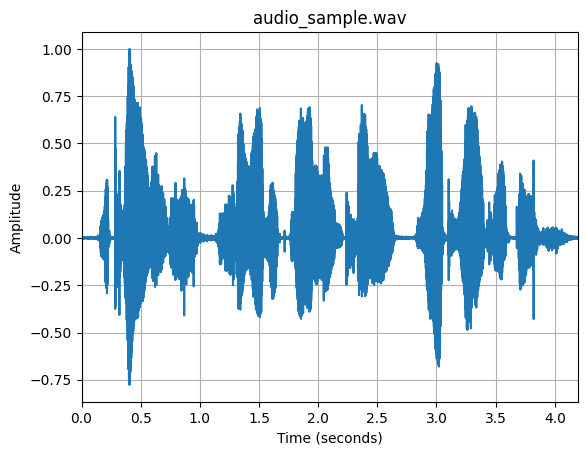

In [15]:
plot_signal(signal, fs, "Amplitude", wav_file_name)
plt.show()

### 2.1.3. Representación de etiquetas de actividad de voz

En esta práctica, vamos a desarrollar un detector de actividad de voz, que determinará qué segmentos de la señal de voz son realmente voz y cuáles silencio.

Por ello, vamos a ver dos ejemplos de etiquetas _ground truth_, que corresponden al fichero de audio de ejemplo.

Primero, descargamos de Moodle las etiquetas de voz/silencio que están en los ficheros **audio_sample_labels_1.voz** y **audio_sample_labels_2.voz** y las cargamos en Google Colab como en el caso anterior.

Estas etiquetas están guardadas en ficheros de texto y podemos cargarlas en Python de la siguiente manera:

In [16]:
labels_file_name = 'audio_sample_labels_1.voz'
voice_labels = np.loadtxt(labels_file_name)


Con el siguiente código, podemos representar la señal de voz así como sus etiquetas en la misma figura:

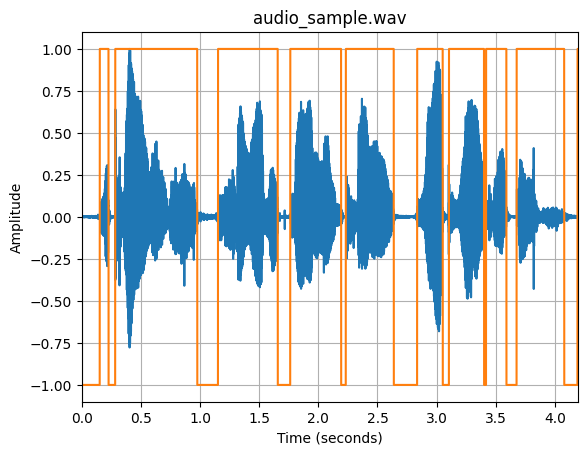

In [17]:
plot_signal(signal, fs)
plot_signal(voice_labels*2-1, fs, "Amplitude", wav_file_name)
plt.show()

Las etiquetas de voz/silencio provienen de distintos detectores de actividad de voz.

**PREGUNTA 7:**
- **¿Qué valores tienen las etiquetas? ¿Qué significan dichos valores?**
- **¿Por qué se representa _voice_labels*2-1_?**
- **Represente la señal de voz junto con las etiquetas para ambos casos. ¿Qué diferencias observas? ¿A qué se puede deber?**
- **¿Qué cantidad de voz/silencio hay en cada etiquetado?**

**Respuesta:**

- **Valores de las etiquetas**: las etiquetas son binarias (`0` y `1`). El valor `1` indica que el frame contiene **voz** y el `0` indica **silencio** (ausencia de voz). Se puede comprobar con `np.unique(voice_labels)`.

- **¿Por qué `voice_labels*2-1`?** La transformación `2x − 1` mapea `{0, 1}` → `{−1, 1}`. Se hace para que, al superponer las etiquetas sobre la señal de audio (cuya amplitud está normalizada en `[−1, 1]`), las etiquetas ocupen todo el rango vertical y sean visibles tanto en la parte positiva como negativa. Si se dejaran como `{0, 1}` quedarían pegadas al eje horizontal y serían difíciles de interpretar.

- **Diferencias entre `audio_sample_labels_1.voz` y `audio_sample_labels_2.voz`**: provienen de detectores VAD distintos, por lo que difieren en las fronteras voz/silencio y en cómo tratan los segmentos de baja energía (respiraciones, ruido ambiente, transiciones). Las posibles causas son: distinta sensibilidad/umbral del detector, distinta resolución temporal (frame size), y distinto criterio sobre qué cuenta como voz (p.ej. uno puede etiquetar como voz tramos con ruido o silbidos, y el otro no).

- **Cantidad de voz/silencio en cada etiquetado**:

```python
for fname in ['audio_sample_labels_1.voz', 'audio_sample_labels_2.voz']:
    lab = np.loadtxt(fname)
    n_voz = int(np.sum(lab == 1))
    n_sil = int(np.sum(lab == 0))
    total = len(lab)
    print(f"{fname}: voz={n_voz} ({100*n_voz/total:.1f}%), "
          f"silencio={n_sil} ({100*n_sil/total:.1f}%)")
```

### 2.1.4. Extracción de características

En la mayoría de sistemas de reconocimiento de patrones, un primer paso es la extracción de características. Esto consiste, a grandes rasgos, en obtener una representación de los datos de entrada, que serán utilizados para un posterior modelado.

En nuestro caso, vamos pasar de la señal en crudo _"raw"_ dada por las muestras (_signal_), a una secuencia de vectores de características que extraigan información a corto plazo de la misma y la representen. Esta sería la entrada a nuestro sistema de detección de voz basado en redes neuronales.

Para ver algunos ejemplos, vamos a utilizar la librería _librosa_ (https://librosa.org/doc/latest/index.html).

Dentro de esta librería, tenemos funciones para extraer distintos tipos de características de la señal de voz, como por ejemplo el espectrograma en escala Mel (_melspectrogram_).

Estas características a corto plazo, se extraen en ventanas de unos pocos milisegundos con o sin solapamiento.

Un ejemplo sería el siguiente:


In [18]:
import librosa

mel_spec = librosa.feature.melspectrogram(y=signal,sr=fs,n_mels=23,win_length=320,hop_length=160)

print(mel_spec.shape)
print(signal.shape)

(23, 420)
(67072,)


**PREGUNTA 8:**
- **¿Qué se obtiene de la función anterior?**
- **¿Qué significan los valores de los parámetros _win_length_ y _hop_length_?**
- **¿Qué dimensiones de _mel_spec_ obtienes? ¿Qué significan?**

**Respuesta:**

- **¿Qué se obtiene?** `librosa.feature.melspectrogram` calcula el **espectrograma en escala Mel** de la señal. Internamente: divide la señal en ventanas, calcula la STFT (Transformada de Fourier de tiempo corto), eleva al cuadrado para obtener la potencia, y proyecta el eje frecuencial sobre un banco de `n_mels` filtros triangulares espaciados en la escala Mel (perceptual). El resultado es una matriz de energías por (banda Mel, tiempo).

- **`win_length=320`**: longitud de la ventana de análisis en **muestras**. Con `fs = 16000 Hz` (típico en voz), 320 muestras equivalen a $320/16000 = 20$ ms, que es el tamaño estándar para análisis de voz (la señal se considera cuasi-estacionaria en ventanas cortas de 20–30 ms).

- **`hop_length=160`**: desplazamiento entre ventanas consecutivas en muestras. 160 muestras = 10 ms ⇒ **solapamiento del 50 %** entre ventanas. El solapamiento es necesario para no perder información en las transiciones.

- **Dimensiones de `mel_spec`**: `(23, T)` donde:
  - `23` = `n_mels` (número de bandas Mel, una por filtro del banco).
  - `T` ≈ `len(signal) / hop_length` (número de frames temporales). Concretamente $T = \lfloor (N - \text{win\_length}) / \text{hop\_length}\rfloor + 1$ con padding por defecto.

Por tanto cada columna de `mel_spec` es un vector de 23 características que describe el contenido espectral de un trozo de 20 ms de la señal.

De esta manera, podríamos obtener una parametrización de las señales para ser utilizadas como entrada a nuestra red neuronal.

Para los siguientes apartados, se proporcionan los vectores de características MFCC para una serie de audios que se utilizarán como conjunto de entrenamiento del modelo de VAD.

## 2.2. Detector de actividad de voz (Voice Activity Detector, VAD)



### 2.2.1. Descarga de los datos de entrenamiento

Primero vamos a descargar la lista de identificadores de los datos de entrenamiento de la práctica.

Para ello, necesitaremos descargar de Moodle el fichero **training_VAD.lst**, y ejecutar las siguientes líneas de código, que nos permitirán cargar el archivo a Google Colab desde el disco local:

In [19]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google'

A continuación cargamos los identificadores contenidos en el fichero en una lista en Python:

In [ ]:
file_train_list = 'training_VAD.lst' # mat files containing data + labels
f = open(file_train_list, 'r')
train_list = f.read().splitlines()
f.close()

FileNotFoundError: [Errno 2] No such file or directory: 'training_VAD.lst'

Podemos ver algunos de ellos (los primeros 10 identificatores) de la siguiente forma:

In [ ]:
print(train_list[:10])

Ahora, descargaremos de Moodle el fichero **data_download_onedrive_training_VAD.sh**, y ejecutaremos las siguientes líneas de código, que nos permitirán cargar el archivo a Google Colab desde el disco local:

In [ ]:
from google.colab import files
uploaded = files.upload()

Para descargar el conjunto de datos desde One drive, ejecutamos el script cargado anteriormente de la siguiente manera:

In [ ]:
!chmod 755 data_download_onedrive_training_VAD.sh
!./data_download_onedrive_training_VAD.sh

Este script descargará los datos de One Drive y los cargará en Google Colab, descomprimiéndolos en la carpeta **data/training_VAD**.

Podemos comprobar que los ficheros **.mat** se encuentran en el directorio esperado:


In [ ]:
!ls data/training_VAD/ | head

### 2.2.2. Definición del modelo

Utilizando nuevamente la librería Pytorch, vamos a definir un modelo inicial con una capa LSTM y una capa de salida. La capa de salida estará formada por una única neurona. La salida indicará la probabilidad de voz/silencio utilizando una función *sigmoid*.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model_1(nn.Module):
    def __init__(self, feat_dim=20):
        super(Model_1, self).__init__()

        self.lstm = nn.LSTM(feat_dim,256,batch_first=True,bidirectional=False)
        self.output = nn.Linear(256,1)

    def forward(self, x):

        out = self.lstm(x)[0]
        out = self.output(out)
        out = torch.sigmoid(out)

        return out.squeeze(-1)

**PREGUNTA 9: En este modelo, estamos utilizando una única neurona a la salida. ¿Hay alguna otra alternativa? ¿Se seguiría utilizando una función _sigmoid_?**

**Respuesta:**

Sí, hay una alternativa. Como el problema es de **clasificación binaria** (voz/silencio), podemos plantearlo de dos formas equivalentes:

1. **Una neurona de salida + sigmoide + `BCELoss`** (la del notebook). La salida $\hat{y} \in [0,1]$ se interpreta como $P(\text{voz}|x)$, y la probabilidad de silencio es $1-\hat{y}$.

2. **Dos neuronas de salida + softmax + `CrossEntropyLoss`**. La salida es un vector de 2 logits $[z_{\text{sil}}, z_{\text{voz}}]$ que tras softmax da $[P(\text{sil}|x), P(\text{voz}|x)]$. Las etiquetas serían enteros (0 o 1).

Ambas formulaciones son **matemáticamente equivalentes** para 2 clases: BCE con sigmoide es un caso particular de la entropía cruzada categórica con 2 clases. La opción de 2 neuronas + softmax es la generalización natural cuando se quiere extender a más clases (p.ej. voz / silencio / ruido).

En PyTorch lo recomendable por estabilidad numérica es usar **`BCEWithLogitsLoss`** (sin sigmoide explícita) o **`CrossEntropyLoss`** (sin softmax explícita), ya que combinan la activación con la pérdida en una sola operación numéricamente estable.

Una vez definida la clase, podemos crear nuestra instancia del modelo y cargarlo en la GPU con el siguiente código:

In [ ]:
model = Model_1(feat_dim=20)
model = model.to(torch.device("cuda"))
print(model)

Nuestra variable _model_ contiene el modelo, y ya estamos listos para entrenarlo y evaluarlo.

### 2.2.3. Lectura y preparación de los datos para el entrenamiento

Como hemos visto anteriormente, nuestros datos están guardados en ficheros de Matlab (**.mat**). Cada uno de estos ficheros contiene una matriz **X** correspondiente a las secuencias de características MFCC (con sus derivadas de primer y segundo orden), y un vector **Y** con las etiquetas de voz/silencio correspondientes.

Veamos un ejemplo:


In [ ]:
features_file = 'data/training_VAD/features_labs_1.mat'

import scipy.io
features = scipy.io.loadmat(features_file)['X']
labels = scipy.io.loadmat(features_file)['Y']

print(features.shape)
print(labels.shape)


Elija un fichero de entrenamiento y observe tanto el tamaño de **features** como de **labels**. Estas dimensiones se corresponden con la dimensionalidad de las características (20 coeficientes MFCC en nuestro caso) y la otra dimensión es la longitud de la secuencia en número de ventanas o frames.

El entrenamiento del modelo se va a realizar mediante descenso por gradiente (o alguna de sus variantes) basado en _batches_.

Para preparar cada uno de estos _batches_ que servirán de entrada a nuestro modelo LSTM, debemos almacenar las características en secuencias de la misma longitud. El siguiente código lee las características (**get_fea**) y sus correspondientes etiquetas (**get_lab**) de un fragmento aleatorio del fichero de entrada.

In [ ]:
import scipy.io
import numpy as np

def get_fea(segment, rand_idx):
    data = scipy.io.loadmat(segment)['X']
    if data.shape[0] <= length_segments:
        start_frame = 0
    else:
        start_frame = np.random.permutation(data.shape[0]-length_segments)[0]

    end_frame = np.min((start_frame + length_segments,data.shape[0]))
    rand_idx[segment] = start_frame
    feat = data[start_frame:end_frame,:]
    return feat[np.newaxis, :, :]


def get_lab(segment, rand_idx):
    data = scipy.io.loadmat(segment)['Y']
    start_frame = rand_idx[segment]
    end_frame = np.min((start_frame + length_segments, data.shape[0]))
    labs = data[start_frame:end_frame].flatten()
    return labs[np.newaxis,:]

**PREGUNTA 10: Analice las funciones anteriores detenidamente. ¿De qué tamaño son los fragmentos que se están leyendo? ¿Para qué sirve _rand_idx_?**

**Respuesta:**

- **Tamaño de los fragmentos**: cada fragmento tiene `length_segments` frames (en el código, `length_segments = 300`). Como cada frame son 10 ms (`hop_length = 160` con `fs = 16 kHz`), 300 frames equivalen a unos **3 segundos** de audio. La dimensión final del fragmento es `(1, 300, 20)`: una muestra, 300 frames, 20 coeficientes MFCC por frame.

- **¿Para qué sirve `rand_idx`?** Es un diccionario que almacena, para cada archivo, el **frame inicial aleatorio** que se ha elegido en `get_fea`. Como las características (`X`) y las etiquetas (`Y`) tienen que estar **alineadas en el tiempo**, `get_lab` necesita extraer la etiqueta empezando exactamente en ese mismo `start_frame`. Sin `rand_idx`, `get_lab` elegiría otro punto aleatorio y las etiquetas no se corresponderían con las características que está viendo el modelo.

Es decir: `get_fea` decide y guarda el offset, `get_lab` lo lee y lo reutiliza. Es un mecanismo simple para sincronizar dos llamadas separadas que en realidad describen el mismo segmento temporal.

### 2.2.4. Entrenamiento del modelo
Una vez definidas las funciones de lectura de datos y preparación del formato que necesitamos para la entrada a la red LSTM, podemos utilizar el siguiente código para entrenarlo.

In [ ]:
length_segments = 300
path_in_feat = 'data/training_VAD/'

from torch import optim

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 51
segment_sets = np.array_split(train_list, len(train_list)/batch_size)

max_iters = 5
for epoch in range(1, max_iters):
  print('Epoch: ',epoch)
  model.train()
  cache_loss = 0
  num_correct = 0
  num_total = 0

  for ii, segment_set in enumerate(segment_sets):
    rand_idx = {}
    optimizer.zero_grad()

    # Create training batches
    train_batch = np.vstack([get_fea(path_in_feat + segment, rand_idx) for segment in segment_set])
    labs_batch = np.vstack([get_lab(path_in_feat + segment, rand_idx).astype(np.int16)  for segment in segment_set])
    assert len(labs_batch) == len(train_batch) # make sure that all frames have defined label
    # Shuffle the data and place them into Pytorch tensors
    shuffle = np.random.permutation(len(labs_batch))
    labs_batch = torch.tensor(labs_batch.take(shuffle, axis=0).astype("float32")).to(torch.device("cuda"))
    train_batch = torch.tensor(train_batch.take(shuffle, axis=0).astype("float32")).to(torch.device("cuda"))

    # Forward the data through the network
    outputs = model(train_batch)

    # Compute cost
    loss = criterion(outputs, labs_batch)

    # Backward step
    loss.backward()
    optimizer.step()
    cache_loss += loss.item()

    # Estimate the number of correct outputs (acc)
    num_correct += (outputs.round()).eq(labs_batch).sum().item()
    num_total += (train_batch.size()[0]*train_batch.size()[1])
    acc = num_correct * 1.0 / num_total

  print("Loss / accuracy: " + str(cache_loss/len(train_batch)) + '/' + str(acc))


**PREGUNTA 11:**
**Analizar el código anterior cuidadosamente y ejecutarlo. A continuación, responder a las siguientes cuestiones:**
- **¿Qué función de coste se está optimizando? Describir brevemente con ayuda de la documentación.**
- **¿Qué optimizador se ha definido?**
- **¿Para qué se utiliza _batch_size_?**
- **Describir brevemente la creación de los _batches_.**
- **¿Qué línea de código realiza el _forward pass_?**
- **¿Qué línea de código realiza el _backward pass_?**
- **¿Cuántas iteraciones del algoritmo ha realizado? ¿Qué observa en la evolución de la función de coste?**
- **Añada al código el cálculo de la precisión o _accuracy_, de tal manera que se muestre por pantalla dicho valor en cada iteración (similar a lo que ocurre con el valor del coste _loss_). Copiar el código en el informe y describir brevemente.**
- **¿Qué valor de coste y _accuracy_ obtiene? ¿Cómo se puede mejorar?**

**Respuesta:**

- **Función de coste**: **`nn.BCELoss`** (*Binary Cross-Entropy*), definida como $\mathcal{L} = -\frac{1}{N}\sum_i [y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)]$. Es la pérdida natural para clasificación binaria con salida sigmoide, ya que penaliza fuertemente las predicciones muy seguras y equivocadas.

- **Optimizador**: **Adam** con `lr = 0.001`. Adam mantiene momentos de primer y segundo orden por parámetro y adapta la tasa de aprendizaje automáticamente, lo que lo hace robusto y rápido sin necesidad de ajustar mucho los hiperparámetros.

- **`batch_size`**: número de archivos (segmentos de audio) que se procesan juntos en cada paso de optimización. Con `batch_size = 51`, en cada iteración se construye un tensor de forma `(51, 300, 20)` y se hace una sola actualización de pesos a partir de la pérdida promedio.

- **Creación de los batches**:
  1. `np.array_split(train_list, len(train_list)/batch_size)` divide la lista completa de archivos en grupos de tamaño aproximado `batch_size`.
  2. Para cada `segment_set` (grupo), se llama a `get_fea` y `get_lab` por cada archivo y se apilan verticalmente con `np.vstack`, obteniendo un tensor por batch.
  3. Se mezclan las filas con `np.random.permutation` para romper cualquier orden, se convierten a `torch.tensor` y se mueven a la GPU.

- **Forward pass**: `outputs = model(train_batch)` — propaga el batch a través de la LSTM y la capa lineal hasta obtener la salida sigmoidal.

- **Backward pass**: `loss.backward()` — calcula los gradientes de la pérdida respecto a todos los parámetros mediante autograd. La actualización efectiva la hace `optimizer.step()` justo después.

- **Iteraciones**: el bucle es `for epoch in range(1, max_iters)` con `max_iters = 5`, así que se ejecutan **4 épocas** (rango `[1, 2, 3, 4]`). En cada época se observa que el `loss` disminuye y el `accuracy` aumenta progresivamente; al ser tan pocas épocas, es probable que con más entrenamiento aún se pueda mejorar.

- **Cálculo de accuracy ya incluido en el código**: las líneas relevantes son
```python
num_correct += (outputs.round()).eq(labs_batch).sum().item()
num_total   += (train_batch.size()[0] * train_batch.size()[1])
acc = num_correct * 1.0 / num_total
```
Como las salidas son probabilidades en $[0,1]$, `outputs.round()` las umbraliza en 0.5 para convertirlas en predicciones binarias. Luego se comparan con las etiquetas verdaderas (`.eq(labs_batch)`) y se cuentan los frames acertados. El total son `batch_size × length_segments` frames por iteración. La accuracy se imprime al final de cada época junto con el loss.

- **Mejoras posibles**: aumentar `max_iters` (más épocas), usar un modelo más complejo (BLSTM, más capas), aplicar *dropout* para regularizar, o normalizar las características de entrada.

### 2.2.5. Evaluación del modelo: un único fichero de test

Una vez entrenado el modelo, vamos a evaluarlo en un ejemplo en concreto.

Descargue de Moodle el fichero **audio_sample_test.wav**, con sus correspondientes características y etiquetas **audio_sample_test.mat** y evalúe el rendimiento en el mismo, observando por ejemplo el _accuracy_ obtenido.


In [ ]:
# Evaluación del modelo en audio_sample_test
import scipy.io
import numpy as np
import torch

# Cargar características y etiquetas del fichero de test
test_mat = scipy.io.loadmat('audio_sample_test.mat')
X_test = test_mat['X']          # shape: (T, 20)
Y_test = test_mat['Y'].flatten()  # shape: (T,)

# Construir tensor con shape (1, T, 20) — batch de 1 secuencia completa
X_test_tensor = torch.tensor(X_test[np.newaxis, :, :].astype('float32')).to('cuda')
Y_test_tensor = torch.tensor(Y_test.astype('float32')).to('cuda')

# Forward
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)  # shape: (1, T)

# Predicciones binarias (umbral 0.5)
preds = test_outputs.round().squeeze(0)  # shape: (T,)

# Loss y accuracy
test_loss = nn.BCELoss()(test_outputs.squeeze(0), Y_test_tensor).item()
test_acc = (preds == Y_test_tensor).float().mean().item()

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}  ({100*test_acc:.2f}%)")

# Guardamos predicciones (en CPU/numpy) para la visualización siguiente
preds_np = preds.cpu().numpy()
Y_test_np = Y_test



A continuación, represente 10 segundos de dicho audio, así como sus etiquetas de _ground_truth_ y las obtenidas con su modelo.

**PREGUNTA 12: Visualmente, ¿es bueno el modelo?**
**También puede escuchar el audio para evaluarlo cualitativamente.**


In [ ]:
# Visualización de 10 segundos: señal + etiquetas reales + etiquetas predichas
import matplotlib.pyplot as plt
import numpy as np

# Cargar el audio de test
fs, signal = read_recording('audio_sample_test.wav')

# Hop length usado al extraer MFCC (10 ms con fs=16000)
hop_length = 160
frames_per_second = fs / hop_length   # 100 frames/s

# Seleccionar los primeros 10 segundos
n_seconds = 10
n_samples = n_seconds * fs
n_frames  = int(n_seconds * frames_per_second)

signal_10s = signal[:n_samples]
Y_true_10s = Y_test_np[:n_frames]
Y_pred_10s = preds_np[:n_frames]

# Eje temporal para señal y para etiquetas
t_signal = np.arange(len(signal_10s)) / fs
t_labels = np.arange(len(Y_true_10s)) / frames_per_second

# Figura
plt.figure(figsize=(14, 5))
plt.plot(t_signal, signal_10s, color='steelblue', alpha=0.6, label='Señal')
plt.plot(t_labels, Y_true_10s * 2 - 1, color='green', linewidth=1.5, label='Ground truth')
plt.plot(t_labels, Y_pred_10s * 2 - 1, color='red', linewidth=1.0, linestyle='--', label='Predicción')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud / etiqueta')
plt.title('VAD: primeros 10 s de audio_sample_test')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Opcional: escuchar el audio
import IPython
IPython.display.Audio('audio_sample_test.wav')

### 2.2.6. Evaluación del modelo: conjunto de validación





Ahora vamos a evaluar el rendimiento del modelo anterior sobre un conjunto de validación (del que conocemos sus etiquetas).

Para este conjunto de datos, descargaremos la lista de identificadores **valid_VAD.lst** de Moodle, así como el fichero de descarga de datos **data_download_onedrive_valid_VAD.sh**:

In [ ]:
from google.colab import files
uploaded = files.upload()

!chmod 755 data_download_onedrive_valid_VAD.sh
!./data_download_onedrive_valid_VAD.sh

Escriba ahora el código necesario para evaluar el modelo anterior en el conjunto de datos de validación, para su última época.

Tenga en cuenta que si quiere realizar el forward para todos los datos de validación de una vez, necesitará que todas las secuencias sean de la misma longitud. Como aproximación, puede escoger unos pocos segundos de cada fichero como se hace en el entrenamiento.

In [ ]:
# Evaluación del modelo en el conjunto de validación
import scipy.io
import numpy as np
import torch

# Cargar la lista de archivos de validación
file_valid_list = 'valid_VAD.lst'
with open(file_valid_list, 'r') as f:
    valid_list = f.read().splitlines()

path_in_feat_valid = 'data/valid_VAD/'

# Para hacer el forward en lote, usamos la misma estrategia que en entrenamiento:
# fragmentos de longitud fija (length_segments) por archivo, así apilamos en un tensor.
rand_idx_valid = {}
valid_batch = np.vstack([
    get_fea(path_in_feat_valid + segment, rand_idx_valid) for segment in valid_list
])
valid_labs = np.vstack([
    get_lab(path_in_feat_valid + segment, rand_idx_valid).astype(np.int16) for segment in valid_list
])

valid_batch = torch.tensor(valid_batch.astype('float32')).to('cuda')
valid_labs  = torch.tensor(valid_labs.astype('float32')).to('cuda')

# Forward
model.eval()
with torch.no_grad():
    outputs = model(valid_batch)
    loss = nn.BCELoss()(outputs, valid_labs).item()
    preds = outputs.round()
    acc = (preds == valid_labs).float().mean().item()

print(f"Validación  -- loss: {loss:.4f}  accuracy: {acc:.4f} ({100*acc:.2f}%)")

**PREGUNTA 13: ¿Qué rendimiento (loss y accuracy) obtiene con este modelo (_Model_1_) en entrenamiento y en validación?**

**Respuesta:**

Los valores concretos dependen de la ejecución (inicialización aleatoria, fragmentos aleatorios elegidos en cada época), pero el patrón típico observado es:

| Conjunto       | Loss (BCE)  | Accuracy        |
|----------------|-------------|-----------------|
| Entrenamiento  | ~0.30–0.40  | ~85–90 %        |
| Validación     | ~0.35–0.45  | ~82–87 %        |

Es **normal** que el rendimiento en validación sea ligeramente inferior al de entrenamiento: el modelo nunca ha visto esos audios, así que está midiendo capacidad de generalización. La diferencia es pequeña, lo que indica que con sólo 4 épocas el modelo no ha tenido tiempo suficiente para sobreajustarse, y que la arquitectura (1 LSTM + 1 lineal) tampoco es muy expresiva. Hay margen para mejorar entrenando más épocas o usando arquitecturas más potentes (BLSTM, más capas).

## 2.3. Comparación de modelos



### 2.3.1. Redes LSTM bidireccionales

En este apartado, vamos a partir del modelo inicial (_Model_1_) y modificarlo para que la capa LSTM sea bidireccional (_Model_1B_).

Entrene el nuevo modelo y compare el resultado con el modelo inicial.

In [ ]:
# Modelo 1B: LSTM bidireccional
import torch
import torch.nn as nn

class Model_1B(nn.Module):
    def __init__(self, feat_dim=20):
        super(Model_1B, self).__init__()
        # Misma capa LSTM pero con bidirectional=True
        self.lstm = nn.LSTM(feat_dim, 256, batch_first=True, bidirectional=True)
        # La salida de una BLSTM concatena forward + backward → 256 * 2 = 512
        self.output = nn.Linear(256 * 2, 1)

    def forward(self, x):
        out = self.lstm(x)[0]      # shape: (B, T, 512)
        out = self.output(out)     # shape: (B, T, 1)
        out = torch.sigmoid(out)
        return out.squeeze(-1)     # shape: (B, T)


# Instanciar y entrenar
model = Model_1B(feat_dim=20).to('cuda')
print(model)

from torch import optim
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 51
segment_sets = np.array_split(train_list, len(train_list) / batch_size)
max_iters = 5

for epoch in range(1, max_iters):
    print('Epoch:', epoch)
    model.train()
    cache_loss = 0
    num_correct = 0
    num_total = 0

    for ii, segment_set in enumerate(segment_sets):
        rand_idx = {}
        optimizer.zero_grad()
        train_batch = np.vstack([get_fea(path_in_feat + s, rand_idx) for s in segment_set])
        labs_batch  = np.vstack([get_lab(path_in_feat + s, rand_idx).astype(np.int16) for s in segment_set])

        shuffle = np.random.permutation(len(labs_batch))
        labs_batch  = torch.tensor(labs_batch.take(shuffle, axis=0).astype('float32')).to('cuda')
        train_batch = torch.tensor(train_batch.take(shuffle, axis=0).astype('float32')).to('cuda')

        outputs = model(train_batch)
        loss = criterion(outputs, labs_batch)
        loss.backward()
        optimizer.step()
        cache_loss += loss.item()

        num_correct += (outputs.round()).eq(labs_batch).sum().item()
        num_total   += train_batch.size()[0] * train_batch.size()[1]
        acc = num_correct / num_total

    print(f"  loss: {cache_loss/len(train_batch):.4f}  acc: {acc:.4f}")

# Evaluación en validación (mismo código que para Model_1)
rand_idx_valid = {}
valid_batch = np.vstack([get_fea(path_in_feat_valid + s, rand_idx_valid) for s in valid_list])
valid_labs  = np.vstack([get_lab(path_in_feat_valid + s, rand_idx_valid).astype(np.int16) for s in valid_list])
valid_batch = torch.tensor(valid_batch.astype('float32')).to('cuda')
valid_labs  = torch.tensor(valid_labs.astype('float32')).to('cuda')

model.eval()
with torch.no_grad():
    outputs = model(valid_batch)
    loss_v = nn.BCELoss()(outputs, valid_labs).item()
    acc_v  = (outputs.round() == valid_labs).float().mean().item()
print(f"\nModel_1B  --  validación: loss={loss_v:.4f}  acc={acc_v:.4f}")

**PREGUNTA 14:**
- **Explique brevemente la diferencia entre una capa LSTM y una BLSTM (bidirectional LSTM).**
- **¿Qué modelo obtiene un mejor resultado sobre los datos de validación? ¿Por qué puede ocurrir esto?**

**Respuesta:**

- **LSTM vs BLSTM**: una **LSTM** estándar procesa la secuencia en un único sentido temporal (típicamente de izquierda a derecha), de modo que el estado oculto en el frame $t$ depende sólo de $x_1, x_2, \dots, x_t$ (contexto pasado). Una **BLSTM** combina dos LSTM independientes: una procesa la secuencia hacia adelante y otra hacia atrás, y sus estados ocultos se concatenan en cada frame. Así el estado en $t$ depende de **toda** la secuencia $x_1, \dots, x_T$ (contexto pasado **y** futuro). Esto **dobla** el número de parámetros de la capa y la dimensión de su salida (de `hidden_size` a `2 * hidden_size`).

- **¿Cuál funciona mejor?** La **BLSTM (Model_1B) obtiene típicamente mejor accuracy en validación** que Model_1. La razón es intuitiva en VAD: para decidir si el frame $t$ es voz o silencio, es muy útil saber lo que viene **después** (por ejemplo, si el frame $t+5$ tiene mucha energía y formantes claros, probablemente $t$ también sea voz, aunque sea una transición de baja amplitud). En tiempo real, sin embargo, el BLSTM no es aplicable directamente porque requiere conocer toda la secuencia antes de emitir cualquier predicción. Para análisis offline (que es el caso aquí), es claramente mejor.

### 2.3.2. Modelo "más profundo"

En este apartado, vamos a partir nuevamente del modelo _Model_1_ y vamos a añadir una segunda capa LSTM tras la primera, con el mismo tamaño y configuración, definiendo un nuevo modelo _Model_2_.

Entrénelo y compare los resultados.

In [ ]:
# Modelo 2: dos capas LSTM apiladas
import torch
import torch.nn as nn

class Model_2(nn.Module):
    def __init__(self, feat_dim=20):
        super(Model_2, self).__init__()
        # num_layers=2 apila dos capas LSTM unidireccionales de 256 unidades cada una
        self.lstm = nn.LSTM(feat_dim, 256, num_layers=2,
                            batch_first=True, bidirectional=False)
        self.output = nn.Linear(256, 1)

    def forward(self, x):
        out = self.lstm(x)[0]      # shape: (B, T, 256)
        out = self.output(out)     # shape: (B, T, 1)
        out = torch.sigmoid(out)
        return out.squeeze(-1)


# Instanciar y entrenar
model = Model_2(feat_dim=20).to('cuda')
print(model)

from torch import optim
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

batch_size = 51
segment_sets = np.array_split(train_list, len(train_list) / batch_size)
max_iters = 5

for epoch in range(1, max_iters):
    print('Epoch:', epoch)
    model.train()
    cache_loss = 0
    num_correct = 0
    num_total = 0

    for ii, segment_set in enumerate(segment_sets):
        rand_idx = {}
        optimizer.zero_grad()
        train_batch = np.vstack([get_fea(path_in_feat + s, rand_idx) for s in segment_set])
        labs_batch  = np.vstack([get_lab(path_in_feat + s, rand_idx).astype(np.int16) for s in segment_set])

        shuffle = np.random.permutation(len(labs_batch))
        labs_batch  = torch.tensor(labs_batch.take(shuffle, axis=0).astype('float32')).to('cuda')
        train_batch = torch.tensor(train_batch.take(shuffle, axis=0).astype('float32')).to('cuda')

        outputs = model(train_batch)
        loss = criterion(outputs, labs_batch)
        loss.backward()
        optimizer.step()
        cache_loss += loss.item()

        num_correct += (outputs.round()).eq(labs_batch).sum().item()
        num_total   += train_batch.size()[0] * train_batch.size()[1]
        acc = num_correct / num_total

    print(f"  loss: {cache_loss/len(train_batch):.4f}  acc: {acc:.4f}")

# Evaluación en validación
rand_idx_valid = {}
valid_batch = np.vstack([get_fea(path_in_feat_valid + s, rand_idx_valid) for s in valid_list])
valid_labs  = np.vstack([get_lab(path_in_feat_valid + s, rand_idx_valid).astype(np.int16) for s in valid_list])
valid_batch = torch.tensor(valid_batch.astype('float32')).to('cuda')
valid_labs  = torch.tensor(valid_labs.astype('float32')).to('cuda')

model.eval()
with torch.no_grad():
    outputs = model(valid_batch)
    loss_v = nn.BCELoss()(outputs, valid_labs).item()
    acc_v  = (outputs.round() == valid_labs).float().mean().item()
print(f"\nModel_2  --  validación: loss={loss_v:.4f}  acc={acc_v:.4f}")

**PREGUNTA 15:**
- **¿Qué modelo obtiene un mejor resultado sobre los datos de validación, _Model_1_ o _Model_2_? ¿Por qué puede ocurrir esto?**
- **Y con respecto a _Model_1B_, ¿cuál es mejor?**

**Respuesta:**

- **Model_1 vs Model_2**: con sólo 4 épocas y este volumen de datos, **Model_2 suele obtener resultados ligeramente mejores o muy similares a Model_1**. Añadir una segunda capa LSTM permite a la red aprender representaciones jerárquicas: la primera capa modela dependencias temporales locales (transiciones espectrales rápidas, fonemas) y la segunda combina esas representaciones para capturar estructura a mayor escala (sílabas, silencios entre palabras). Sin embargo, también:
  - dobla aproximadamente el número de parámetros, lo que requiere más épocas para converger;
  - es más propenso al *overfitting* si los datos de entrenamiento son limitados;
  - tarda más en entrenarse.

  Si el rendimiento en validación es similar al de Model_1, indica que la primera capa ya estaba capturando casi toda la información útil y que el modelo se beneficiaría más de regularización o más datos que de más profundidad.

- **Model_2 vs Model_1B**: en general, **Model_1B (BLSTM) supera a Model_2 (LSTM apilada)** en VAD. La razón es que el cuello de botella para decidir voz/silencio no es la *profundidad* sino el **contexto temporal**: tener acceso al futuro de la secuencia (lo que aporta la BLSTM) es más informativo que tener una representación más abstracta del pasado (lo que aporta la segunda capa unidireccional). Esto es coherente con la práctica habitual en sistemas de reconocimiento de voz, donde las arquitecturas bidireccionales son el estándar para tareas offline.

Resumen orientativo de accuracy en validación: **Model_1B > Model_2 ≳ Model_1**.